# Quickstart: NDVI in eight lines

The shortest useful Easy-EO workflow: open a scene, compute a vegetation index, look at it, and save the result.

- **Data:** the bundled Sentinel-2 sample
- **Network:** only for the first download of the sample

In [1]:
%matplotlib inline

## The whole thing

Everything below is elaboration on these lines.

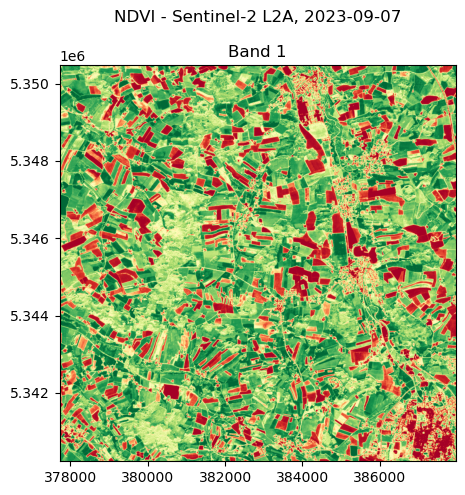

In [2]:
from eeo import load_raster
from eeo.datasets import load_sample_dataset

sd = load_sample_dataset()
scene = load_raster(sd.sentinel2_stacked)

ndvi = scene.ndvi(red="red", nir="nir")
ndvi.plot_raster(cmap="RdYlGn", title="NDVI - Sentinel-2 L2A, 2023-09-07")

## What just happened

`load_raster` opens the file but reads **no pixel data** - it hands back an `EEORasterDataset` describing the scene. Pixels are read only when an operation needs them.

In [3]:
scene.describe()

EEORasterDataset
  source      : /home/tommy/.cache/easy-eo/sentinel2_small.tif
  driver      : GTiff
  bands       : 4
  band names  : 1: blue, 2: green, 3: red, 4: nir
  size        : 1024 × 1024  (height × width)
  dtype       : uint16
  crs         : EPSG:32633 — WGS 84 / UTM zone 33N
  pixel size  : 10 × 10  (CRS units)
  extent      : 377720, 5340230, 387960, 5350470  (minx, miny, maxx, maxy)
  nodata      : 0.0
  timestamp   : none
  attrs       : none


The sample carries its band names in the file itself, so bands are addressable as `"red"` and `"nir"` instead of as numbers. Any band argument also accepts a 1-based integer (`scene.ndvi(red=3, nir=4)`) or a separate single-band dataset, so the same call works however your data is organised.

In [4]:
print(scene.band_names)

['blue', 'green', 'red', 'nir']


## Look at the scene first

A true-colour composite from the red, green and blue bands. The percentile stretch is what turns dark satellite reflectance into a readable image.

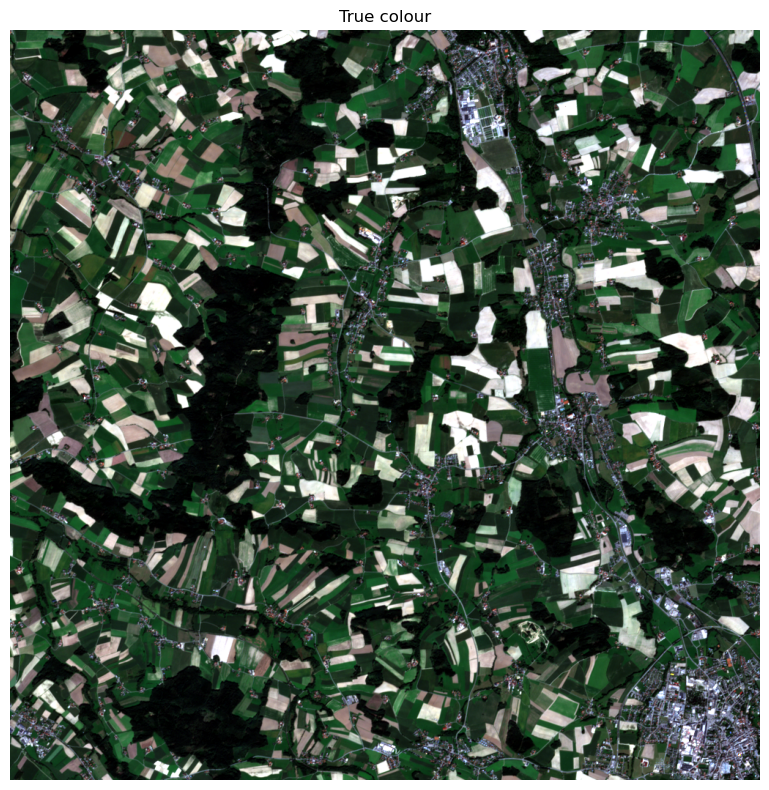

In [5]:
scene.plot_composite(["red", "green", "blue"], pmin=2, pmax=98, title="True colour")

## The index itself

`ndvi()` is a thin, documented wrapper over the algebra primitives: `(NIR - Red) / (NIR + Red)`. Like every index in Easy-EO it returns a **new** single-band dataset - the input is never modified - with **float32** output and `NaN` wherever any input pixel was nodata.

In [6]:
print("dtype :", ndvi.get_metadata()["dtype"])
print("nodata:", ndvi.get_metadata()["nodata"])
print("bands :", ndvi.get_count())
print("crs   :", ndvi.get_crs(), "- unchanged from the input")

dtype : float32
nodata: nan
bands : 1
crs   : EPSG:32633 - unchanged from the input


In [7]:
import numpy as np

values = ndvi.get_band(1)
print(f"min {np.nanmin(values):.3f}   median {np.nanmedian(values):.3f}   max {np.nanmax(values):.3f}")

min -0.107   median 0.502   max 0.737


A histogram alongside the map is usually more informative than either alone.  
This scene is farmland in late summer: the bulk of pixels sit between 0.3 and
0.7, which is healthy vegetation.

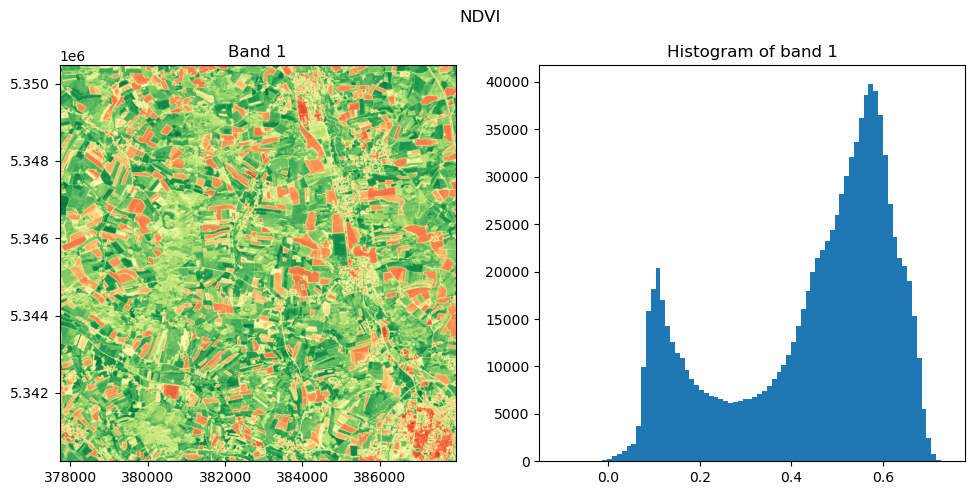

In [8]:
ndvi.plot_raster_with_histogram(cmap="RdYlGn", bins=80, title="NDVI")

## Chaining

Operations return datasets, so they compose. Here NDVI is stretched to its 2nd and 98th percentiles before plotting - one expression, no intermediate variables.

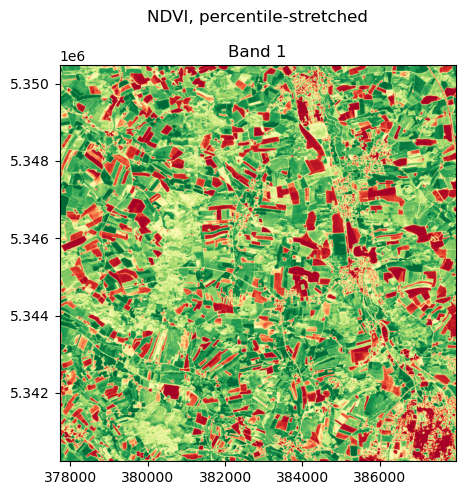

In [9]:
(
    scene.ndvi(red="red", nir="nir")
    .normalize_percentile(lower_percentile=2, upper_percentile=98)
    .plot_raster(cmap="RdYlGn", title="NDVI, percentile-stretched")
)

## Save it

`save_raster` writes a GeoTIFF carrying the CRS, transform and nodata of the result, so it opens correctly in QGIS or anything else that reads GeoTIFF.

In [10]:
import tempfile
from pathlib import Path

out_dir = Path(tempfile.mkdtemp())
ndvi.save_raster(str(out_dir / "ndvi.tif"))

written = load_raster(str(out_dir / "ndvi.tif"))
written.describe()

EEORasterDataset
  source      : /tmp/tmpl70acmph/ndvi.tif
  driver      : GTiff
  bands       : 1
  band names  : none
  size        : 1024 × 1024  (height × width)
  dtype       : float32
  crs         : EPSG:32633 — WGS 84 / UTM zone 33N
  pixel size  : 10 × 10  (CRS units)
  extent      : 377720, 5340230, 387960, 5350470  (minx, miny, maxx, maxy)
  nodata      : nan
  timestamp   : none
  attrs       : none


In [11]:
for ds in (scene, ndvi, written):
    ds.close()

## Next

- **[../01_fundamentals/01_reading_and_inspecting](../01_fundamentals/01_reading_and_inspecting.ipynb)** - what a dataset is and how to interrogate it
- **[../01_fundamentals/04_band_algebra_and_indices](../01_fundamentals/04_band_algebra_and_indices.ipynb)** - all six indices and the algebra underneath them
- **[../03_real_world/01_flood_mapping_ndwi](../03_real_world/01_flood_mapping_ndwi.ipynb)** - the same ideas applied to a real flood